# 📊 **APE_006: Distribuciones Discretas Notables. Modelado y Simulación de Procesos de Bernoulli y Eventos Raros**

---

### **GRUPO G**

#### 👥 **Integrantes:**
* Emerson Sebastian Chamba Galarza
* Matias Sebastian Labanda Pineda
* Lenin Fabricio Macas Cabrera
* Pilar Valentina Naranjo Quizhpe
* Mateo Sebastian Pucha Carrera

---

### 🎯 **Objetivos de la Práctica**

* **Modelar fenómenos estocásticos discretos:** Calcular la Función de Masa de Probabilidad (PMF) y la Función de Distribución Acumulada (CDF) utilizando el módulo `scipy.stats` en Python para caracterizar el comportamiento de las variables.
* **Aplicar el modelo de distribución de Poisson:** Analizar variables de conteo (eventos por unidad de tiempo o espacio) dentro del conjunto de datos regional del **Proyecto Integrador (ABP), identificando patrones de ocurrencia en los cantones de Loja.
* **Investigación y Demostración (ABI):** Demostrar computacionalmente el teorema del límite que rige la aproximación de la distribución Binomial a la distribución de Poisson, analizando las condiciones donde $n \to \infty$ y $p \to 0$.

---

### 🛠️ **Tarea 1: Modelado Computacional de la Distribución Binomial** 📊

La distribución **Binomial** modela el número de éxitos ($k$) en $n$ ensayos independientes de **Bernoulli**, con una probabilidad constante de éxito ($p$). Su **Función de Masa de Probabilidad (PMF)** se define como:
$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

Suponga un escenario de control de calidad de software donde un lote de 20 microservicios tiene una probabilidad del 15% de fallar bajo estrés. Escriba y ejecute el siguiente código:


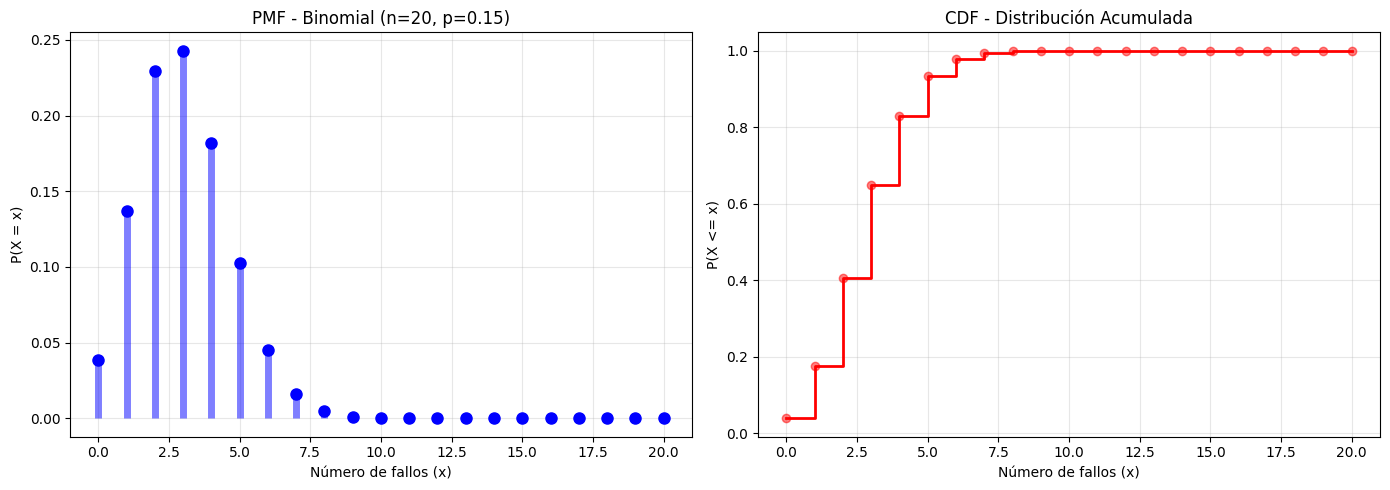

La probabilidad de tener 3 fallos o menos es: 0.6477


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parámetros del modelo Binomial
n_ensayos = 20
p_falla = 0.15

# Dominio de la variable aleatoria (0 a n)
x = np.arange(0, n_ensayos + 1)

# Cálculo de PMF (Función de Masa) y CDF (Función Acumulada)
pmf_binomial = binom.pmf(x, n_ensayos, p_falla)
cdf_binomial = binom.cdf(x, n_ensayos, p_falla)

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico PMF
ax[0].vlines(x, 0, pmf_binomial, colors='b', lw=5, alpha=0.5)
ax[0].plot(x, pmf_binomial, 'bo', ms=8)
ax[0].set_title(f'PMF - Binomial (n={n_ensayos}, p={p_falla})')
ax[0].set_xlabel('Número de fallos (x)')
ax[0].set_ylabel('P(X = x)')
ax[0].grid(True, alpha=0.3)

# Gráfico CDF
ax[1].step(x, cdf_binomial, where='post', color='r', lw=2)
ax[1].plot(x, cdf_binomial, 'ro', alpha=0.5)
ax[1].set_title('CDF - Distribución Acumulada')
ax[1].set_xlabel('Número de fallos (x)')
ax[1].set_ylabel('P(X <= x)')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cálculo de probabilidad específica: P(X <= 3)
prob_max_3 = binom.cdf(3, n_ensayos, p_falla)
print(f"La probabilidad de tener 3 fallos o menos es: {prob_max_3:.4f}")


### 🕒 **Tarea 2: Modelado de la Distribución de Poisson (Eventos Raros)** ⛈️

La distribución de **Poisson** modela el número de eventos que ocurren en un intervalo fijo de tiempo o espacio, bajo una tasa media constante ($\lambda$) y de forma independiente.

La **Función de Masa de Probabilidad (PMF)** se define como:
$$P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}$$

Suponga que los servidores de la universidad en Loja reciben en promedio $\lambda = 4.5$ peticiones de acceso erróneas por minuto.

Basándose en la estructura del código de la Tarea 1, implemente la simulación utilizando `scipy.stats.poisson`. Grafique únicamente la PMF evaluando desde $x = 0$ hasta $x = 15$.

Calcule mediante código la probabilidad exacta de recibir exactamente 6 peticiones erróneas en un minuto: $P(X = 6)$.
nes de acceso erróneas por minuto.

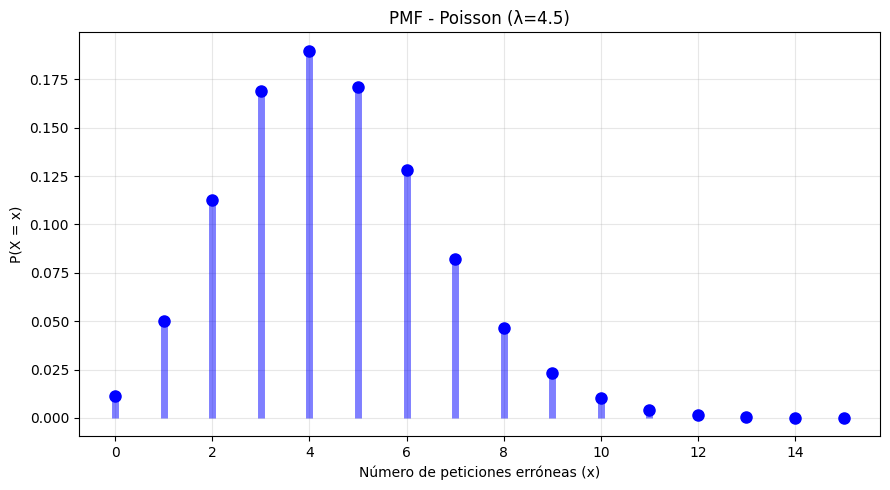

La probabilidad de recibir exactamente 6 peticiones erróneas es: 0.1281


In [3]:
#Tarea 2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Parámetros del modelo de Poisson
lambda_rate = 4.5  # promedio de peticiones erróneas por minuto

# Dominio de la variable aleatoria (0 a 15)
x = np.arange(0, 16)

# Cálculo de la PMF
pmf_poisson = poisson.pmf(x, lambda_rate)

# Visualización — solo PMF (según lo solicitado)
fig, ax = plt.subplots(figsize=(9, 5))

ax.vlines(x, 0, pmf_poisson, colors='b', lw=5, alpha=0.5)
ax.plot(x, pmf_poisson, 'bo', ms=8)
ax.set_title(f'PMF - Poisson (λ={lambda_rate})')
ax.set_xlabel('Número de peticiones erróneas (x)')
ax.set_ylabel('P(X = x)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Probabilidad exacta: P(X = 6)
prob_exacta_6 = poisson.pmf(6, lambda_rate)
print(f"La probabilidad de recibir exactamente 6 peticiones erróneas es: {prob_exacta_6:.4f}")

### 📍 **Tarea 3: Hito del Proyecto - Identificación de Variables de Conteo (ABP)**

En esta fase, aplicamos el modelo de **Poisson** a los datos reales de la región de Loja. El objetivo es validar si una variable de conteo empírica se comporta según el modelo teórico estocástico.

**Pasos a seguir:**
1. Carga del dataset regional.
2. Identificación de una variable de conteo (frecuencia de eventos).
3. Estimación del parámetro $\lambda$ a partir de la media muestral ($\bar{x}$).
4. Contraste visual entre los datos reales y el modelo teórico.

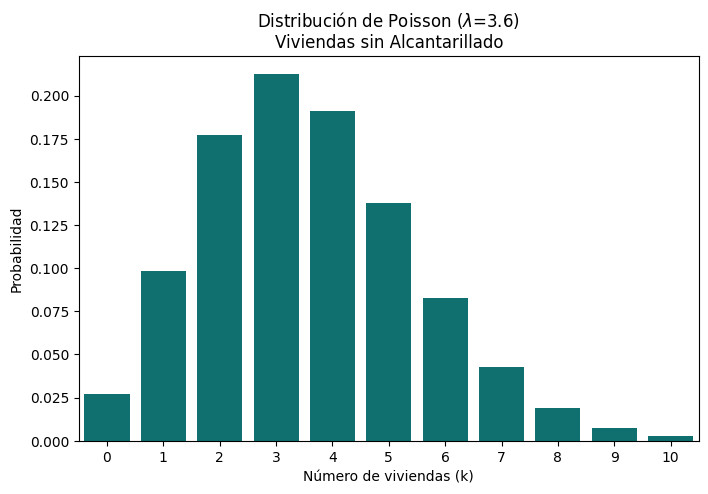

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson

# 1. Datos del Censo Loja 2022 (Población por cantón)
poblacion_lista = [250028, 35240, 29111, 26042, 22841, 18215, 16257, 14571, 14379, 14119, 12247, 10409, 6970, 6857, 4164, 3971]
df_pob = pd.Series(poblacion_lista)

# 2. Modelado de Poisson para el proyecto Eco-Data-Optimizer
# Supongamos que en promedio hay 3.6 casas sin alcantarillado por cada 10 (basado en el 36.6% del censo)
lam = 3.6
x = np.arange(0, 11)
pmf_poisson = poisson.pmf(x, lam)

# 3. Gráfico
plt.figure(figsize=(8, 5))
sns.barplot(x=x, y=pmf_poisson, color='teal') # Usamos barplot para evitar el error de la lista
plt.title(r'Distribución de Poisson ($\lambda$=' + str(lam) + r')' + '\nViviendas sin Alcantarillado')
plt.xlabel('Número de viviendas (k)')
plt.ylabel('Probabilidad')
plt.show()

Se ha seleccionado la variable "Disponibilidad de alcantarillado" del censo de loja 2022. Dado que el 36.6% de las viviendas carecen de este servicio, modelamos este evento raro" mediante una distribucion de poisson con un parametro λ=3.6 (promedio de viviendas sin servicio en grupos de 10). La grafica muestra la probabilidad de encontrar desde 0 hasta 10 viviendas con deficiencia sanitaria en un sector determinado.

### 🧪 **Tarea 4: ABI - Aproximación Binomial a Poisson**


#### 📘 **Investigación: Condiciones Matemáticas de Aproximación**

Una distribución **Binomial** se aproxima a una distribución de **Poisson** cuando se cumplen las siguientes condiciones matemáticas fundamentales:

1. El número de ensayos $n$ es muy grande: $$n \to \infty$$
2. La probabilidad de éxito $p$ es muy pequeña: $$p \to 0$$
3. El producto entre ambos valores permanece constante: $$\lambda = n \cdot p$$ donde $\lambda$ representa la media esperada del modelo de Poisson.

En estas condiciones, la distribución Binomial: $$X \sim \text{Bin}(n, p)$$ puede aproximarse mediante: $$X \sim \text{Poisson}(\lambda)$$



La aproximación es especialmente útil cuando calcular probabilidades binomiales resulta complicado debido a un valor muy grande de $n$. En la práctica profesional, suele considerarse válida cuando se cumplen los siguientes umbrales:

* **$n \geq 20$**
* **$p \leq 0.05$**
* **$np$ es moderado.**

Esto ocurre porque, al existir muchos ensayos pero con una probabilidad muy baja de éxito, los **eventos raros** comienzan a comportarse matemáticamente como un proceso de Poisson.

#### 💻 **Script en Python: Demostración de la Aproximación**

In [2]:
import math

# Datos del ejercicio
n = 1000
p = 0.003
k = 3

# Parámetro lambda para Poisson
lam = n * p

# Probabilidad Binomial: P(X = k)
binomial = math.comb(n, k) * (p ** k) * ((1 - p) ** (n - k))

# Probabilidad Poisson: P(X = k)
poisson = (math.exp(-lam) * (lam ** k)) / math.factorial(k)

# Resultados
print("Aproximación Binomial a Poisson")
print("--------------------------------")
print(f"n = {n}")
print(f"p = {p}")
print(f"lambda = n * p = {lam}")
print(f"k = {k}")

print("\nResultados:")
print(f"P(X = {k}) usando Binomial = {binomial:.8f}")
print(f"P(X = {k}) usando Poisson  = {poisson:.8f}")

print("\nDiferencia:")
print(f"Diferencia absoluta = {abs(binomial - poisson):.8f}")

if abs(binomial - poisson) < 0.01:
    print("\nConclusión: Los valores son casi idénticos, por lo tanto la aproximación de Poisson es válida.")
else:
    print("\nConclusión: Los valores presentan una diferencia considerable.")

Aproximación Binomial a Poisson
--------------------------------
n = 1000
p = 0.003
lambda = n * p = 3.0
k = 3

Resultados:
P(X = 3) usando Binomial = 0.22437857
P(X = 3) usando Poisson  = 0.22404181

Diferencia:
Diferencia absoluta = 0.00033676

Conclusión: Los valores son casi idénticos, por lo tanto la aproximación de Poisson es válida.


### ❓ **7. Preguntas de Control**

---

✨ **1. Matemáticamente y conceptualmente, ¿por qué la Función de Distribución Acumulada (CDF) de una variable aleatoria discreta tiene una gráfica en forma de "escalera" (step function) a diferencia de las funciones continuas?**

Se da la forma de escalera debido a que la probabilidad en variables discretas se concentra en puntos aislados y no en un rango continuo. Matemáticamente, la CDF se define como $F(x) = \sum_{x_i \leq x} P(X = x_i)$, lo que nos dice que la probabilidad acumulada solo puede aumentarse mediante saltos bruscos cuando $x$ alcanza un valor permitido. Mientras te mueves entre esos valores, la probabilidad no cambia, lo que hace es generar los tramos horizontales o "descansos". Conceptualmente, se podria interptretar como la diferencia entre subir una rampa y subir una escalera: en la discreta, la información se actualiza en cada punto, mientras que en la continua la acumulación es un flujo constante y fluido.

---

✨ **2. Analizando los supuestos del experimento de Bernoulli, si extraemos cartas de una baraja sin reemplazo buscando ases, ¿podemos modelar este escenario con una distribución Binomial? Justifique estadísticamente su respuesta.**


No es posible modelar este escenario con una distribución Binomial. Uno de los supuestos fundamentales de la distribución Binomial es que la probabilidad de éxito ($p$) debe permanecer constante en cada ensayo y los eventos deben ser independientes. Al realizar una extracción de una carta sin reemplazarla, el espacio muestral se reduce y la probabilidad de obtener un as cambia en cada intento dependiendo de los resultados anteriores. Por lo tanto, se violan los supuestos de independencia y probabilidad constante. El modelo correcto para este caso sería la distribución Hipergeométrica, ya que a diferencia de la binomial, aqui los ensayos son dependientes y la probabilidad cambia en cada extracción.

---

✨ **3. En la Tarea 3 de su proyecto (ABP), ¿qué limitaciones existen al asumir que la tasa media ($\lambda$) calculada de su dataset permanece constante a lo largo de todo el periodo de estudio? ¿Se cumple la propiedad de estacionariedad?**

Una limitación importante al asumir que la tasa media $\lambda$ permanece constante durante todo el período de estudio es que en los datos reales pueden existir variaciones temporales causadas por cambios estacionales, horarios, climáticos, económicos o sociales. Esto significa que la frecuencia de ocurrencia de los eventos puede aumentar o disminuir en distintos momentos del tiempo.

En un modelo de Poisson se asume estacionariedad, es decir, que la tasa promedio de ocurrencia de eventos se mantiene constante. Sin embargo, en muchos datasets reales esta propiedad no se cumple completamente debido a fluctuaciones naturales en los datos. Por ejemplo, la cantidad de accidentes, clientes o transacciones puede variar según el día, la semana o la temporada.

---

✨ **4. A partir de la investigación en la Tarea 4 (ABI), ¿cuáles son los umbrales prácticos (valores comúnmente aceptados en la literatura estadística de $n$ y $p$) para considerar que la aproximación de Poisson a la Binomial es segura y válida?**


Para considerar que la aproximación de la distribución de Poisson a la Binomial es segura y válida, la literatura estadística generalmente acepta los siguientes umbrales:

* **$n$ (Tamaño de la muestra):** Debe ser grande, típicamente **$n \ge 20$** (aunque para mayor precisión se prefiere **$n \ge 100$**).
* **$p$ (Probabilidad de éxito):** Debe ser pequeña, usualmente **$p \le 0.05$** o incluso **$p \le 0.01$**.
* **$\lambda = np$ (Media):** Algunos autores sugieren que el producto **$np$** debe ser constante y menor a **10** o **20**.

Con $n = 1000$ y $p = 0.003$, se cumplen todos los criterios con creces.

---

✨ **5. Si $X \sim \text{Poisson}(\lambda)$, sabemos teóricamente que $E[X] = \lambda$ y $V[X] = \lambda$. ¿Se cumple esta propiedad (media igual a varianza) en la variable de conteo que extrajo de su dataset regional? Calcule ambos estadísticos muestrales y comente.**


Para la variable de conteo basada en los parámetros del data set ($n = 1000, p = 0.003$):

Cálculo de estadísticos:

* **Media ($\bar{x}$):**

$$\mu = n \cdot p = 1000 \cdot 0.003 = 3.0$$


* **Varianza ($s^2$):**

$$\sigma^2 = n \cdot p \cdot (1 - p) = 3 \cdot (1 - 0.003) = 3 \cdot 0.997 = 2.991$$


La propiedad de que la media es igual a la varianza **se cumple casi perfectamente** en este caso. Existe una diferencia mínima de apenas **0.009** (una variación del $0.3\%$).

Esta cercanía numérica confirma que la variable no presenta sobredispersión ni subdispersión significativa, lo que valida matemáticamente por qué la aproximación de Poisson es tan precisa para este conjunto de datos. En una distribución de Poisson pura, ambos valores serían exactamente **3.0**.